# GLMS in RStan IV
# GLMs in RStan Summary

# Outline
<ul>
    <li>Recap: Bayesian Data Analysis</li>
    <li>Choosing Priors</li>
    <li>MCMC Sampling</li>
    <li>Recap: Bayesian Linear Modeling</li>
    <ul>
        <li>Recap: Robust Regression</li>
    </ul>
    </br>
    <li>Generalized Linear Models (GLMs)</li>
    <li>The Fishing Dataset</li>
    <li>Poisson Regression</li>
    <li>Negative Binomial Regression</li>
    <li>Gamma Regression</li>
    <li>Bayesian Model Comparison</li>
    <ul>
        <li>WAIC</li>
        <li>PSIS-LOO</li>
    </ul>
    </br>
    <li>Zero-Inflated Models</li>
    <ul>
        <li>Zero-Inflated Poisson (ZIP) Regression</li>
        <li>Zero-Inflated Negative Binomial (ZINB) Regression</li>
        <li>Zero-Augmented Gamma Regression</li>
    </ul>
    </br>
    <li>Comparison of Models</li>
</ul>

In a <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VII%20-%20Bayesian%20Modeling%20in%20RStan.ipynb">previous artice</a>, I discussed Bayesian linear modeling using <code>stan</code>, through the R package <code>rstan</code>. In this article, we go beyond linear models using the normal distribution, or t-distribution for robustness to outliers, and discuss methods which produce outcomes constrained to be positive real numbers, or positive integers. We'll discuss Poisson regression, negative binomial regression, and gamma regression, as well as their zero-inflated counterparts for data with large numbers of zeros. We'll perform Bayesian methods of model comparison to evaluate each model's fit against the data.

# Recap: Bayesian Data Analysis

Bayesian data analysis could be viewed as a subset of statistical analysis, though one could argue the opposite. The point is, it is distinct in that quantities are expressed and analyzed probabilistically, meaning in terms of probability distributions, and the theory is supported by Bayes' theorem, which describes the probability of an event based on knowledge or conditions related to that event. In the context of linear modeling, it can express probability intervals for the data which are more straightforwardly interpreted than frequentist confidence intervals, and quantifies uncertainty in model parameters by use of probability distributions rather than p-values.

$P(A|B) = \frac{P(B|A)P(A)}{P(B)} = \frac{\text{likelihood } \times \text { prior}}{\text{marginal likelihood}}$

When searching for model parameters $\theta$, we write:

$f(\theta|y) = \frac{f(y|\theta)f(\theta)}{f(y)} = \frac{f(y|\theta)f(\theta)}{\int f(y|\theta)f(\theta) ~d \theta}$

The denominator can be hard or impossible to integrate, so in many cases we focus on proportionality of the numerator to the result, and use approximation methods which leverage the central limit theorem. More on this in a bit. The term labelled a 'prior' represents our knowledge of the model prior to incorporating the data, and can be viewed as an opportunity to eliminate outcomes that are implausible or unlikely, in the event that our data is too weak (small and/or noisy) to do so on it's own. To this end, it is a good practice to perform prior predictive checks on a model.

# Choosing Priors

We often speak of weakly informative priors as 'regularizing', and indeed they are. For example, ridge regression can be interpreted as normal regression with normal priors on the coefficients, and lasso regression can be seen as normal regression with Laplace priors on the coefficients. When it comes to the Bayesian inference engine of Markov Chain Monte Carlo (MCMC) sampling, proper priors will help to stabilize the exploration of the search space. There are many ways to choose priors, and it's generally preferred to make them at least weakly informative.

In the following, I resort to data-based priors, from prior experimentation. This is not necessarily a recommended method, but it will do for the sake of demonstration, and will make for a 'fair' approach, for the sake of model comparison. A strategy one might use in practice is to center the data, thereby providing information about the expected mean, and/or standardize the data, providing information about the expected standard deviation (particularly with a normal-like distribution).

Conveniently, the Poisson distribution can be defined in terms of only its mean, and the negative binomial and gamma distribution can have their parameters expressed in terms of a mean and standard deviation. This makes it relatively easy to determine priors for their parameters based on simple statistics about the expected data. More on this as we get to each type of distribution individually.

# Markov Chain Monte Carlo (MCMC) Sampling

MCMC sampling is our alternative to relying on closed-form computation, which would only be possible in special cases. It leverages the central limit theorem to derive statistical estimates through samples that approximate the true value of the target distribution. MCMC generates a sequence of samples from a Markov chain whose stationary distribution is the target distribution $P(x)$. The samples are correlated, so the 'effective sample size' is less than the total sample, but this correlation does not harm the results (unless something goes wrong). Many algorithms, such as the Metropolis-Hastings algorithm, use an acceptance-rejection mechanism that sometimes rejects the proposed samples. This is essential to ensuring the success of samples reflecting the target distribution, which is proportional to the posterior.

$P(\theta|D) \propto P(D|\theta)P(\theta)$

The prior is incorporated directly into the target distribution for sampling, thereby influencing the probability of accepting or rejecting proposals, which are made based on the relative likelihoods of proposed parameter values given the data. The acceptance probability for Metropolis-Hastings is:

$\alpha = min \left( 1, \frac{P(\theta^*|D)}{P(\theta_t|D)} \right) = min \left( \frac{P(D|\theta^*)P(\theta)}{P(\theta_t) P(\theta_t)} \right)$

- $\theta^*$ represents the proposed parameter value for the next step
- $\theta_t$ represents the current parameter value at step $t$

Following a warmup process in which samples are discarded, a posterior distribution of generated samples forms the basis of our inference. The parameters themselves have parameters, which unless deterministic, are expressed as probability distributions.

# Recap: Bayesian Linear Modeling

In a linear relationship, where the noise is Gaussian-distributed around the dependent variable, we write:

$y \sim \mathcal{N}(\alpha + \beta x, \sigma)$

where $\alpha$ is the intercept of the linear relationship between $x$ and $y$, and $\beta$ is the slope. $\sigma$ is the noise inherent to the stochastic nature of $y$.

## Recap: Robust Regression

In the <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VII%20-%20Bayesian%20Modeling%20in%20RStan.ipynb">previous article</a>, I covered how regressing with a t-distribution makes the slope-line more resistant to outliers, because of the larger tails (it also compresses the generated samples). The t-distribution can be parameterized in a form that includes a center and location, which is how you will encounter it in <code>stan</code>. As with the normal, the mean and standard deviation are named <code>mu</code> and <code>sigma</code> respectively.

$
\text{StudentT}(y|\nu,\mu,\sigma) = \frac{\Gamma\left((\nu +
1)/2\right)}      {\Gamma(\nu/2)} \ \frac{1}{\sqrt{\nu \pi} \ \sigma}
\ \left( 1 + \frac{1}{\nu} \left(\frac{y - \mu}{\sigma}\right)^2
\right)^{-(\nu + 1)/2} \! .
$

- $\nu$ is the degrees of freedom
- $\Gamma$ is the gamma function

As our model, we write:

$y \sim \text{StudentT}(\text{df}, \alpha + \beta x, \sigma)$

# Generalized Linear Models (GLMs)

We can continue as we did above with the normal and t-distribution, replacing them with arbitrary distributions, and using regression upon another variable to determine (at least) one of the distribution's parameters. The software may get a little more finicky, as we apply additional constraints to the output, but I've found <code>stan</code> to prove useful even when MLE-based methods fail due to numerical instability.

If a parameter is constrained to be positive, such as lambda for the Poisson, mu and phi for the negative binomial, and shape and rate (a.k.a. alpha and beta) for the gamma, it is common to use a link function. This simply means we apply a function to the calculation which constrains it as we please, and the model learns to regress upon the transformed parameter. We will use a log-link function, which means we exponentiate the calculation of the parameter, but can get back to probabilistic terms by working with the logarithm.

# The Fishing Dataset

The dataset we'll use for each model is the <code>Fish</code> dataset that comes with the <code>rethinking</code> package of R. It provides us with 6 variables, describing the number of fish caught by visitors to a campground, along with various visitor features. It has 3 count variables, 2 binary variables, and one positive real-valued variable.

- <code>fish_caught</code>: the number of fish caught by the group of visitors
- <code>livebait</code>: whether the group brought live bait for fishing
- <code>camper</code>: whether the group camped there
- <code>persons</code>: number of people in the group
- <code>child</code>: number of children in the group
- <code>hours</code>: number of hours the group stayed for

Our ultimately dependent variable is number of fish caught, but we'll also model hours as a function of <code>camper</code> and <code>child</code>.

Before loading and visualizing the data, we'll install and load all of the packages that will be used below.

In [ ]:
# # using Google Colab

# install.packages("BiocManager")
# library("BiocManager")

# BiocManager::install("rstan")
# BiocManager::install("devtools")
# devtools::install_github("stan-dev/cmdstanr")
# BiocManager::install(c("coda","mvtnorm","devtools","loo","dagitty"))
# devtools::install_github("rmcelreath/rethinking")
# BiocManager::install("GGally")
# BiocManager::install("corrplot")
# BiocManager::install("corpcor")
# BiocManager::install("bnlearn")
# BiocManager::install("Rgraphviz")

library(rstan)
library(rethinking) # for model comparison
library(GGally) # for pair plots
library(corrplot) # for corr matrix
library(corpcor) # for partial corr
library(bnlearn) # for DAG
library(Rgraphviz) # for DAG

Loading the data:

In [2]:
data <- subset(read.csv('https://raw.githubusercontent.com/pw598/Articles/refs/heads/main/data/fish.csv', row.names=NULL), select = -1)
colnames(data)

[1] "fish_caught" "livebait"    "camper"      "persons"     "child"      
[6] "hours"

And inspecting:

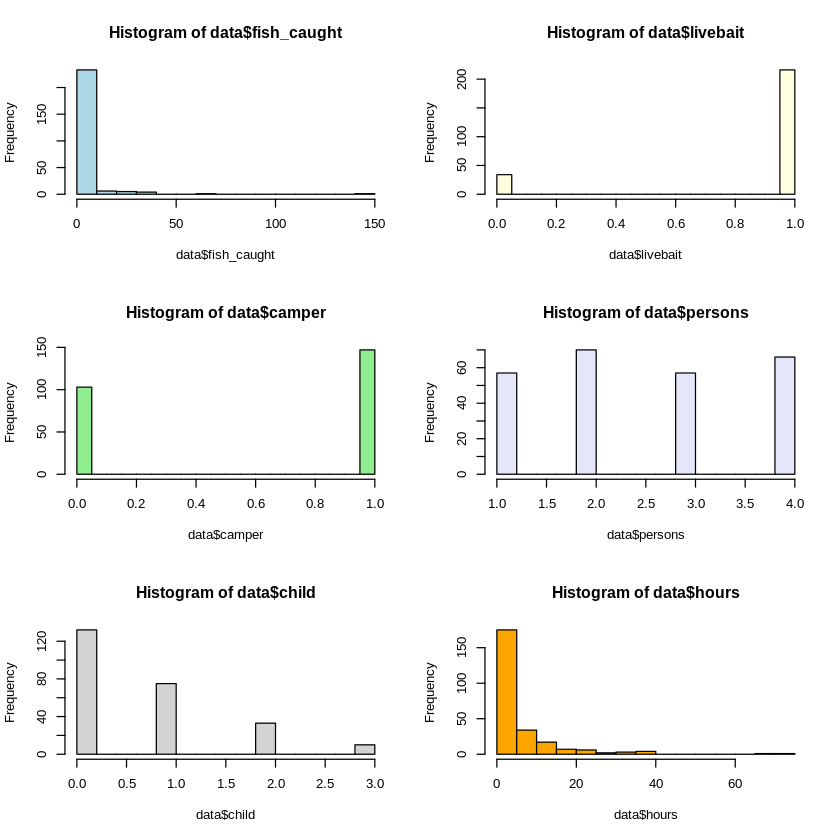

In [ ]:
par(mfrow=c(3,2))
hist(data$fish_caught, breaks=15, col="lightblue")
hist(data$livebait, breaks=15, col="lightyellow")
hist(data$camper, breaks=15, col="lightgreen")
hist(data$persons, breaks=15, col="lavender")
hist(data$child, breaks=15, col="lightgray")
hist(data$hours, breaks=15, col="orange")

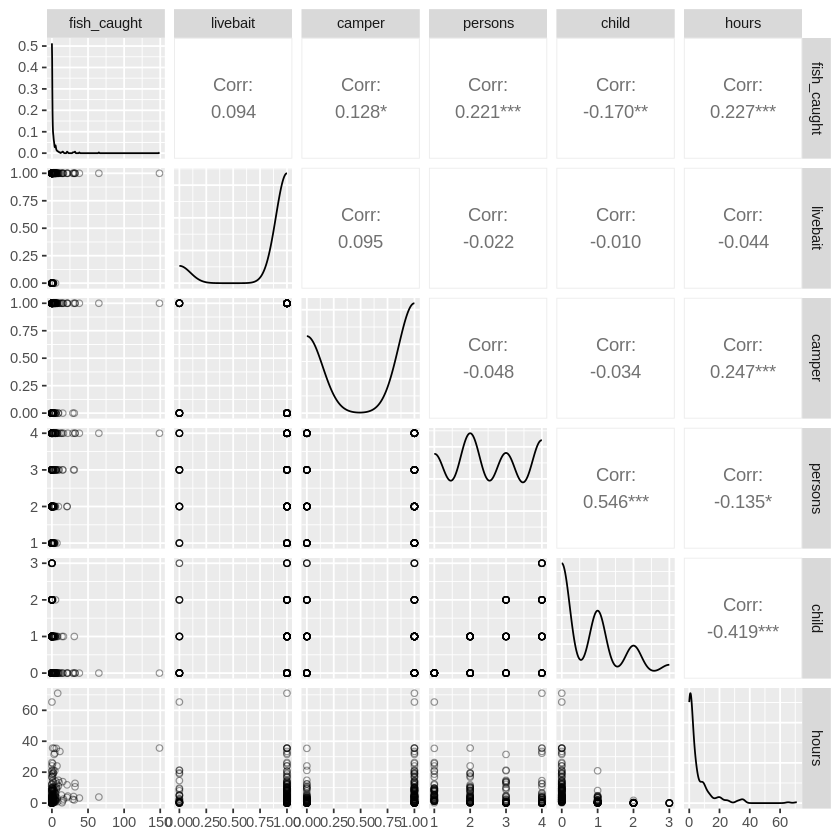

In [ ]:
ggpairs(data,
        lower = list(continuous = wrap("points", alpha = 0.4, shape = 1)),)

Below we take a look at a correlation matrix:

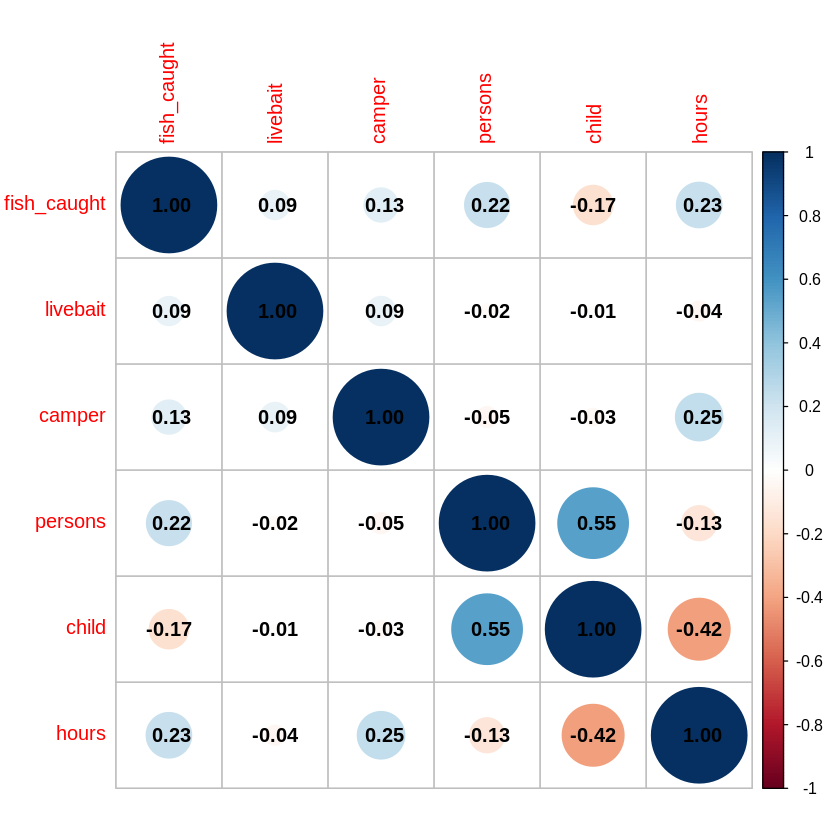

In [ ]:
cor_matrix <- cor(data)
corrplot(cor_matrix, addCoef.col = "black")

And partial correlation:

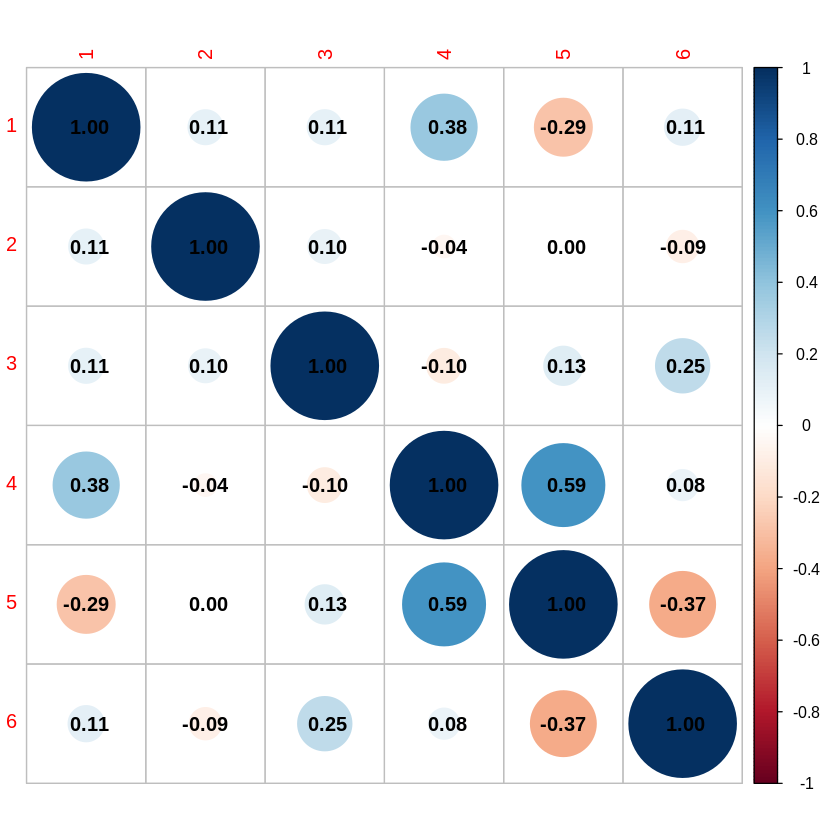

In [ ]:
partial_cor_matrix <- cor2pcor(cor_matrix)
corrplot(partial_cor_matrix, addCoef.col = "black")

For fun, we'll model <code>hours</code> as a function of <code>camper</code> and <code>child</code>, but focus on number of fish caught as the primary interest.

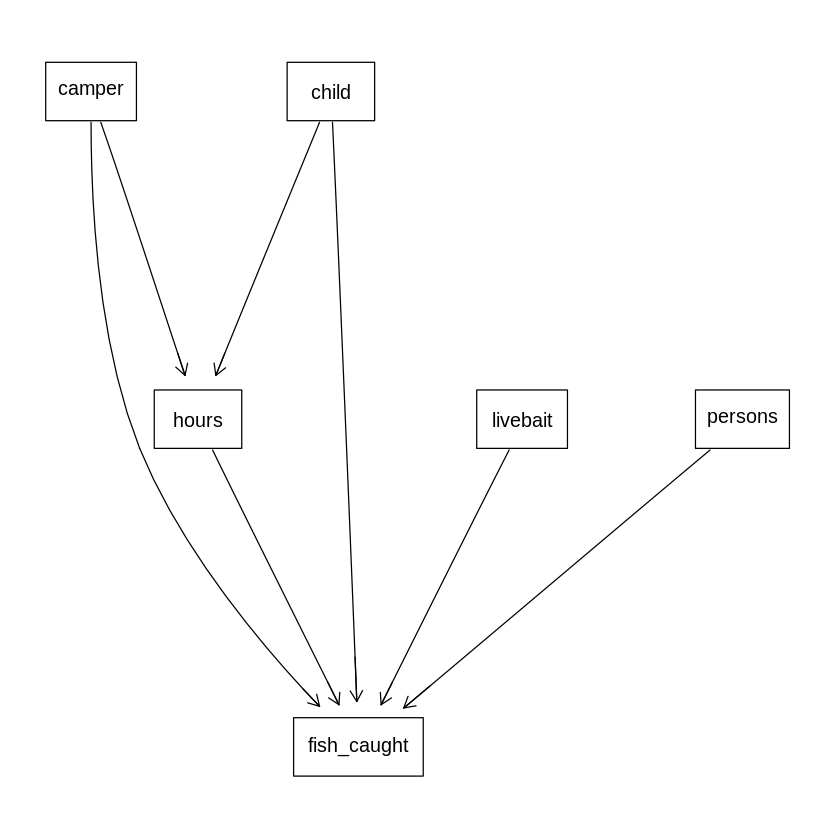

In [ ]:
modelstr <- "[persons][child][camper][livebait][hours|camper:child][fish_caught|persons:child:camper:hours:livebait]"
dag <- model2network(modelstr)
graphviz.plot(dag)

# Poisson Regression

The Poisson distribution models count data, where the mean is assumed to be (approximately) equal to the variance.

$P(Y=y|\lambda) = \frac{\lambda^y e^{-\lambda}}{y!}$

- $E(X) = \lambda$
- $Var(X) = \lambda$

A log-link function models the relationship between the predictors and $\lambda$, which means:

- $log(\lambda) = \alpha + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_p x_p$

- $\lambda = e^{\alpha + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_p x_p}$

Therefore, the coefficients represent the log change in the expected count for a one-unit change in the corresponding predictor.

- $\beta_j = log \left( \frac{\lambda(x+1)}{\lambda(x)} \right)$

- $e^{\beta_j} = \frac{\lambda(x+1)}{\lambda(x)}$

If you are unfamiliar with the C++ library <code>stan</code>, which we will work with through <code>rstan</code> you may want to reference the <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VII%20-%20Bayesian%20Modeling%20in%20RStan.ipynb">previous article</a>, or <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20I%20-%20Poisson%20and%20ZIP%20Regression.ipynb">this workbook</a> on the subject of Poisson regression specifically. There are various types of code blocks available, and we'll restrict it to 4 for simplicity.

In <code>data{}</code>, we declare the variables we are passing in from the R environment, including the size of our dataset, <code>N</code>. In the <code>parameters{}</code> block, we declare the names and types of parameters that we will require the model to analyze. In the <code>model{}</code> block, we declare prior distributions (or alternatively, let it default to flat ones) followed by statements expressing the variable and parameter relationships to the data. In a regression with only normal values, we could do it in vectorized fashion, but with other types of distributions, we are to some extent forced to construct loops. Finally, in the generated quantities block, we capture quantities from our sampling process, from which to draw inference. This last block is optional, we would still have access to the sampled parameter values from the <code>model_fit</code> object without it, just not the predicted data.

In [3]:
stan_code <- "

  data {
      int<lower=0> N;
      int<lower=0> caught[N];
      int<lower=0, upper=1> livebait[N];
      int<lower=0, upper=1> camper[N];
      int<lower=0> persons[N];
      int<lower=0> child[N];
      vector[N] hours;
  }

  parameters {
      real alpha_caught, alpha_hours;
      real beta_hours, beta_livebait, beta_camper, beta_persons, beta_child;
      real beta_child_hours, beta_camper_hours;
      real hours_rate;
      vector<lower=0, upper=1>[N] theta_camper, theta_livebait;
      real lambda_child;
  }

  model {
      // Priors
      alpha_caught ~ normal(-3.4, 0.3);
      alpha_hours ~ normal(0.004, 0.11);
      beta_livebait ~ normal(1.7, 0.25);
      beta_camper ~ normal(0.8, 0.09);
      beta_child ~ normal(-1.7, 0.08);
      beta_hours ~ normal(0, 0.1);
      beta_child_hours ~ normal(-0.94, 0.07);
      beta_camper_hours ~ normal(0.65, 0.09);
      hours_rate ~ normal(0.19, 0.02);
      lambda_child ~ normal(0.7, 0.05);
      theta_camper ~ normal(0.6, 0.05);
      theta_livebait ~ normal(0.86, 0.02);

      // Likelihood
      for (n in 1:N) {
        real lambda = exp(alpha_caught +
                          beta_livebait * livebait[n] +
                          beta_camper * camper[n] +
                          beta_persons * persons[n] +
                          beta_child * child[n] +
                          beta_hours * hours[n]);

        caught[n] ~ poisson(lambda);

        hours[n] ~ gamma(exp(alpha_hours +
                             beta_child_hours * child[n] +
                             beta_camper_hours * camper[n]),
                         hours_rate);

        camper[n] ~ bernoulli(theta_camper);
        livebait[n] ~ bernoulli(theta_livebait);
        child[n] ~ poisson(lambda_child);
      }
  }

  generated quantities{
      int caught_pred[N];
      vector[N] hours_pred;
      int camper_pred[N];
      int livebait_pred[N];
      int child_pred[N];
      real persons_pred[N];
      vector[N] lambda_pred;
      vector[N] log_lik;

      for (n in 1:N) {
          camper_pred[n] = bernoulli_rng(theta_camper[n]);
          child_pred[n] = poisson_rng(lambda_child);
          persons_pred[n] = round(uniform_rng(1,4));
          livebait_pred[n] = bernoulli_rng(theta_livebait[n]);

          hours_pred[n] = gamma_rng(exp(alpha_hours +
                                        beta_child_hours * child_pred[n] +
                                        beta_camper_hours * camper_pred[n]),
                                    hours_rate);

          lambda_pred[n] = exp(alpha_caught +
                                beta_hours * hours_pred[n] +
                                beta_camper * camper_pred[n] +
                                beta_child * child_pred[n]);

          caught_pred[n] = poisson_rng(lambda_pred[n]);

          log_lik[n] = poisson_lpmf(caught[n] | lambda_pred[n]);
      }
  }
  "

The last line, <code>log_lik[n] = poisson_lpmf(caught[n] | lambda_pred[n]);</code>, is only necessary because of the model comparison functions we want to use later on. The <code>rethinking</code> package has convenient model evaluations functions, which we simply call upon the fitted model object, however it requires this <code>log-lik</code> variable to be present in the generated quantities. What we're doing is tracking the log-likelihoods of the predicted parameters within the loop in which those parameters are generated, because this is required by the evaluation algorithms, and the <code>rethinking</code> functions will look for a variable with this name specifically. More on this subject when we get to model comparison.

The <code>stan</code> function of the <code>rstan</code> package we are working with requires the data to be passed into the <code>data</code> block of the C++ code to be in the format of a list, so we construct one as follows, and provide the following arguments to the function, in addition to the model code and data list:

- <code>warmup</code>: a number of iterations to sample for before retaining results, to help stabilize the nature of the search space.
- <code>iter</code>: the number of samples to generate (and retain) post-warmup, for each chain.
- <code>chains</code>: the number of independently initialized sampling procedures to run.
- <code>refresh</code>: whether to print results and debug statements while sampling.
- <code>cores</code>: the number of processors to utilize (not quite in parallel, but it's better than baseline).

In [ ]:
caught <- data$fish_caught
livebait <- data$livebait
camper <- data$camper
persons <- data$persons
child <- data$child
hours <- data$hours
N <- nrow(data)

data_list <- list(N = N, caught = caught, hours = hours,
                  camper = camper, livebait = livebait,
                  child = child, persons = persons)

poisson_model <- rstan::stan(model_code = stan_code, data = data_list, warmup = 2000,
                 iter = 2500, chains = 3, refresh = 0, cores = 8)

We can run some trace plots to inspect the sampling, hoping to see stationary but noisy patterns for each chain and each parameter.

'pars' not specified. Showing first 10 parameters by default.



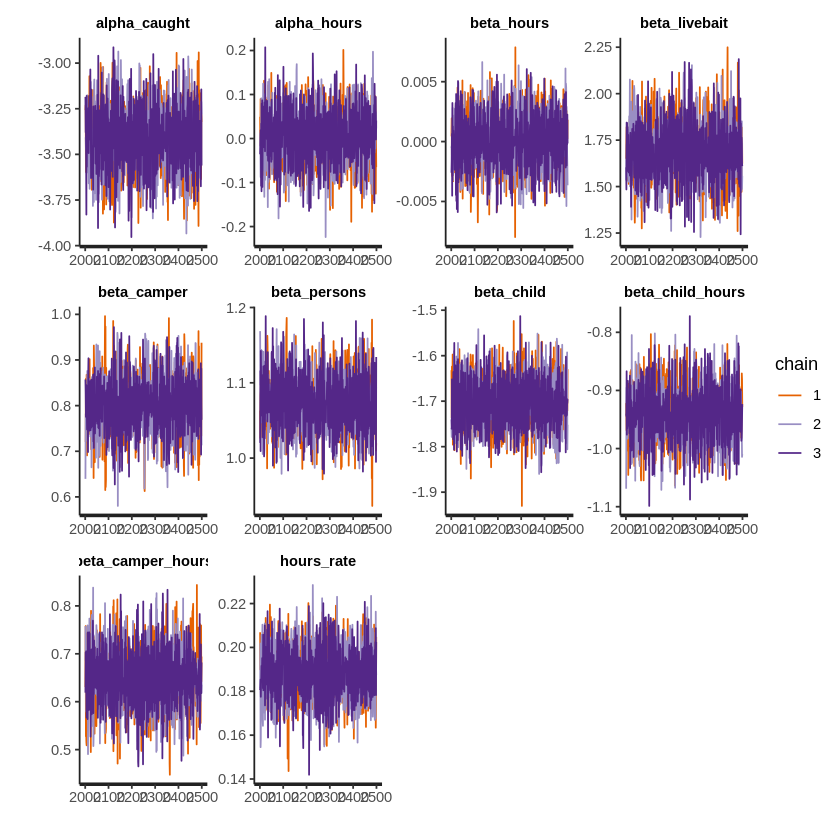

In [9]:
rstan::traceplot(poisson_model)

We use the <code>extract</code> function to extract the samples; I'm in the habit of calling it through <code>rstan</code>, to avoid any potential conflict with functions of the same name from other packages.

In [10]:
posterior_samples <- rstan::extract(poisson_model)

Then, we visualize the results.

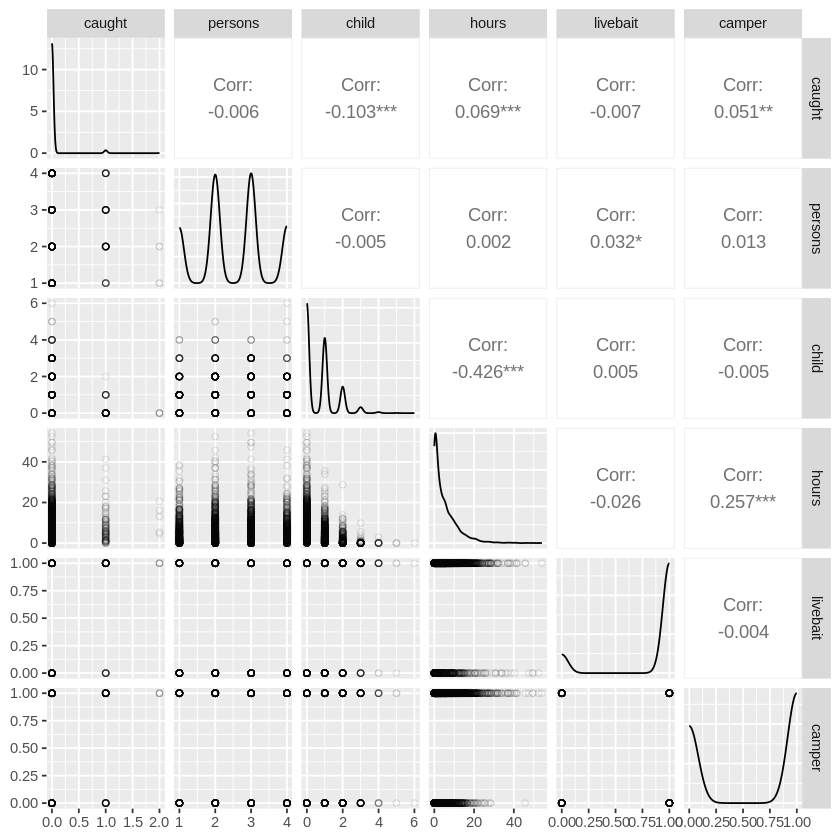

In [11]:
pred_df <- data.frame(caught = as.vector(posterior_samples$caught_pred),
                      persons = as.vector(posterior_samples$persons_pred),
                      child = as.vector(posterior_samples$child_pred),
                      hours = as.vector(posterior_samples$hours_pred),
                      livebait = as.vector(posterior_samples$livebait_pred),
                      camper = as.vector(posterior_samples$camper_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 4000), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.1, shape = 1)),)

Side-by-side histograms of the dependent variable as seen in the data vs. the generated quantities may look similar at first glance, but notice the scale of the x-axis. The Poisson model has difficulty producing values more extreme than 2, whereas the data produces x-axis values up to 150.

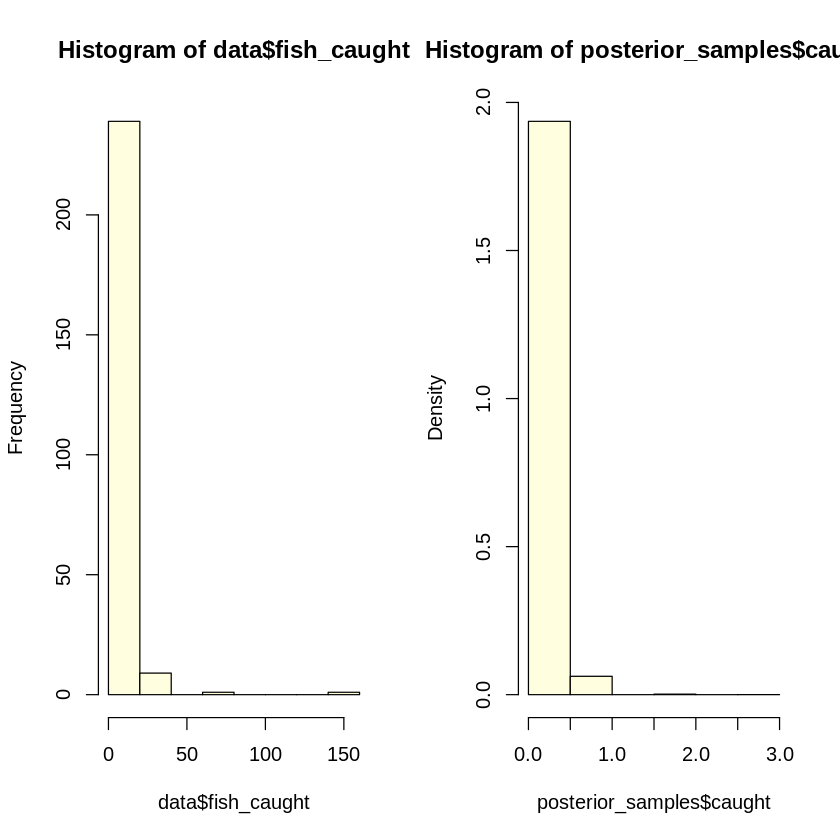

In [12]:
par(mfrow=c(1,2))
hist(data$fish_caught, breaks=10, col="lightyellow")
hist(posterior_samples$caught, breaks=10, col="lightyellow", probability=TRUE)

# Negative Binomial Regression

The negative binomial distribution produces positive count outcomes, but unlike the Poisson, can handle variance that is unequal to the mean. One common parameterization is in terms of $\alpha$ and $\beta$:

$f(y|\alpha, \beta) = \binom{y + \alpha - 1}{\alpha - 1} \left( \frac{\beta}{\beta + 1} \right)^{\alpha} \left( \frac{1}{\beta+1} \right)^y$

- $E(Y) = \frac{\alpha}{\beta}$
- $Var(Y) = \frac{\alpha}{\beta^2}(\beta + 1)$

This is the parameterization of the first version of the negative binomial model provided in <code>stan</code>. However, we will use a more intuitive version, parameterized in terms of the expected value $\mu$ and a dispersion parameter $\phi$. This is the parameterization of the <code>neg_binomial_2</code> model in <code>stan</code>.

$f(y|\mu,\phi) = \binom{y + \phi - 1}{y} \left( \frac{\mu}{\mu + \phi} \right) \left( \frac{\phi}{\mu + \phi} \right)^{\phi}$

- $E(Y) = \mu$
- $Var(Y) = \mu + \frac{\mu^2}{\phi}$.

The Poisson has variance $\mu$, so $\frac{\mu^2}{\phi}$ is the additional variance of the negative binomial above that of the Poisson. The $\mu$ parameter is what we will determine via regression, setting:

- $y \sim \text{NB}(\alpha + \beta x, \phi)$

In [15]:
stan_code <- "

  data {
      int<lower=0> N;
      int<lower=0> caught[N];
      int<lower=0, upper=1> livebait[N];
      int<lower=0, upper=1> camper[N];
      int<lower=0> persons[N];
      int<lower=0> child[N];
      vector[N] hours;
  }

  parameters {
      real alpha_caught, alpha_hours;
      real beta_hours, beta_livebait, beta_camper, beta_persons, beta_child;
      real beta_child_hours, beta_camper_hours;
      real hours_rate;
      vector<lower=0, upper=1>[N] theta_camper, theta_livebait;
      real lambda_child;
      real phi_caught;
  }

  model {
      // Priors
      alpha_caught ~ normal(-3.1, 0.5);
      alpha_hours ~ normal(0.00, 0.11);
      beta_livebait ~ normal(1.57, 0.42);
      beta_camper ~ normal(0.49, 0.23);
      beta_child ~ normal(-1.8, 0.21);
      beta_hours ~ normal(0.01, 0.015);
      beta_child_hours ~ normal(-0.94, 0.07);
      beta_camper_hours ~ normal(0.65, 0.1);
      hours_rate ~ normal(0.19, 0.02);
      lambda_child ~ normal(0.7, 0.05);
      theta_camper ~ normal(0.6, 0.05);
      theta_livebait ~ normal(0.86, 0.02);
      phi_caught ~ normal(0.5, 0.08);

      // Likelihood
      for (n in 1:N) {
        real mu = exp(alpha_caught +
                      beta_livebait * livebait[n] +
                      beta_camper * camper[n] +
                      beta_persons * persons[n] +
                      beta_child * child[n] +
                      beta_hours * hours[n]);

        caught[n] ~ neg_binomial_2(mu, phi_caught);

        hours[n] ~ gamma(exp(alpha_hours +
                             beta_child_hours * child[n] +
                             beta_camper_hours * camper[n]),
                         hours_rate);

        camper[n] ~ bernoulli(theta_camper);
        livebait[n] ~ bernoulli(theta_livebait);
        child[n] ~ poisson(lambda_child);
      }
  }

  generated quantities{
      int caught_pred[N];
      vector[N] hours_pred;
      int camper_pred[N];
      int livebait_pred[N];
      int child_pred[N];
      real persons_pred[N];
      vector[N] mu_pred;
      vector[N] log_lik;

      for (n in 1:N) {
          camper_pred[n] = bernoulli_rng(theta_camper[n]);
          child_pred[n] = poisson_rng(lambda_child);
          persons_pred[n] = round(uniform_rng(1,4));
          livebait_pred[n] = bernoulli_rng(theta_livebait[n]);

          hours_pred[n] = gamma_rng(exp(alpha_hours +
                                        beta_child_hours * child_pred[n] +
                                        beta_camper_hours * camper_pred[n]),
                                    hours_rate);

          mu_pred[n] = exp(alpha_caught +
                            beta_hours * hours_pred[n] +
                            beta_camper * camper_pred[n] +
                            beta_child * child_pred[n]);

          caught_pred[n] = neg_binomial_2_rng(mu_pred[n], phi_caught);

          log_lik[n] = neg_binomial_2_lpmf(caught[n] | mu_pred[n], phi_caught);
      }
  }
  "

We run the model,

In [ ]:
caught <- data$fish_caught
livebait <- data$livebait
camper <- data$camper
persons <- data$persons
child <- data$child
hours <- data$hours
N <- nrow(data)

data_list <- list(N = N, caught = caught, hours = hours,
                  camper = camper, livebait = livebait,
                  child = child, persons = persons)

nb_model <- rstan::stan(model_code = stan_code, data = data_list, warmup = 2000,
                 iter = 2500, chains = 3, refresh = 0, cores = 8)

Inspect the sampling,

'pars' not specified. Showing first 10 parameters by default.



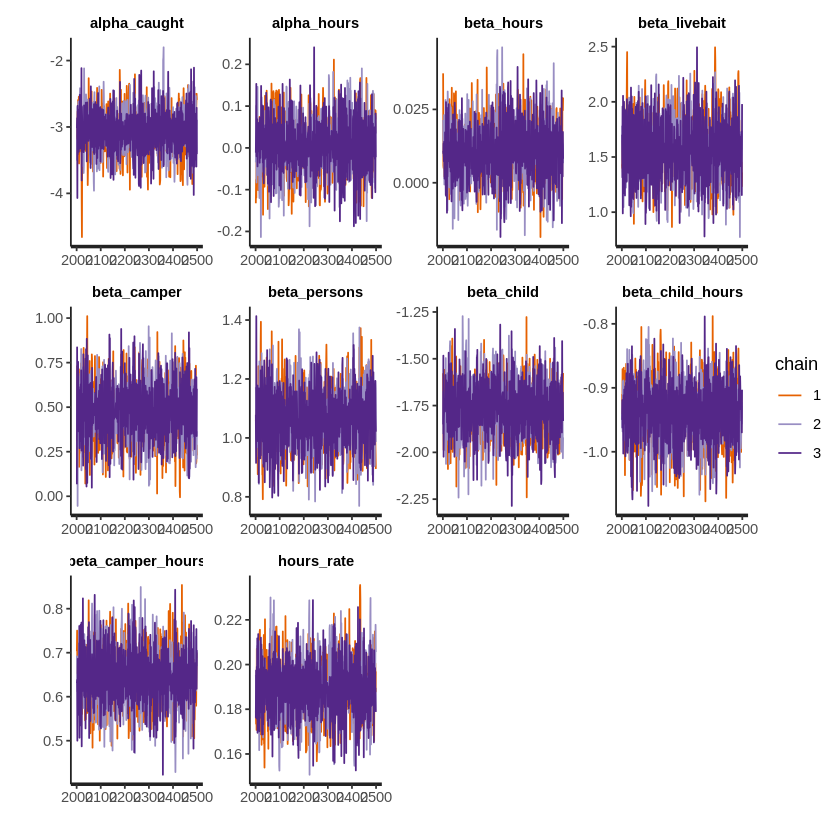

In [19]:
rstan::traceplot(nb_model)

And then extract the sammples and visualize the predictions.

In [20]:
posterior_samples <- rstan::extract(nb_model)

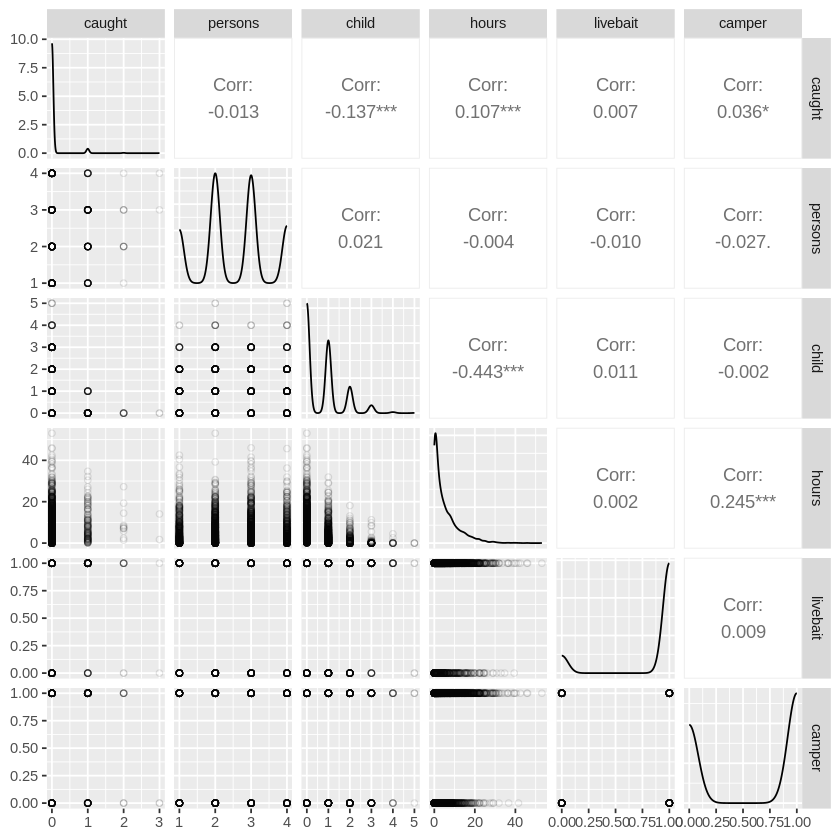

In [21]:
pred_df <- data.frame(caught = as.vector(posterior_samples$caught_pred),
                      persons = as.vector(posterior_samples$persons_pred),
                      child = as.vector(posterior_samples$child_pred),
                      hours = as.vector(posterior_samples$hours_pred),
                      livebait = as.vector(posterior_samples$livebait_pred),
                      camper = as.vector(posterior_samples$camper_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 4000), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.1, shape = 1)),)

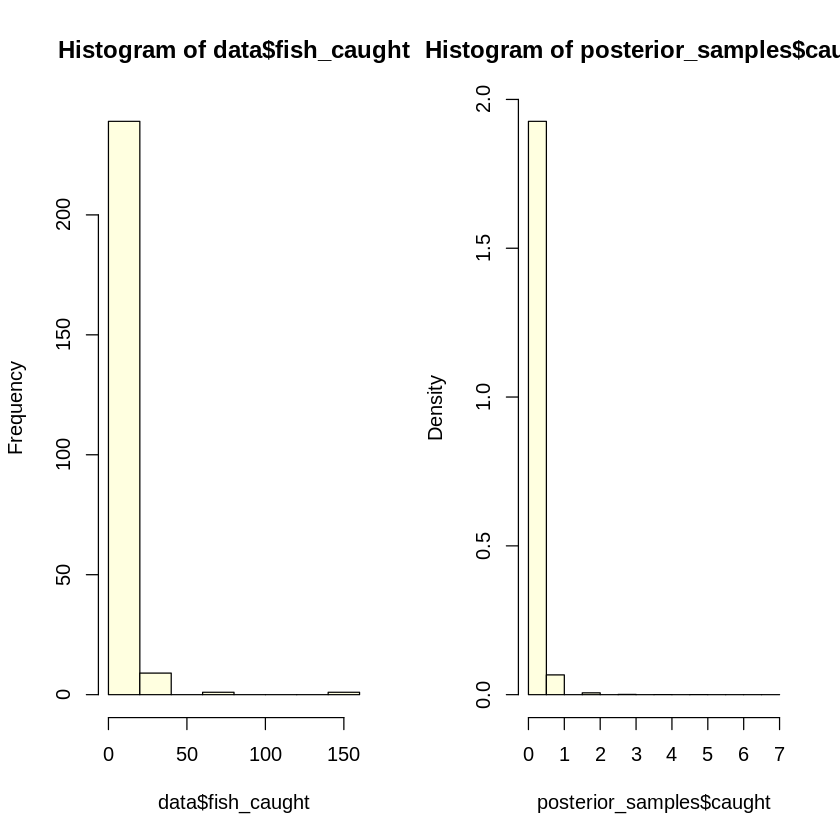

In [22]:
par(mfrow=c(1,2))
hist(data$fish_caught, breaks=10, col="lightyellow")
hist(posterior_samples$caught, breaks=10, col="lightyellow", probability=TRUE)

We see a little more range than the Poisson, but are far from having replicated the range of the data.

# Gamma Regression

Finally, before delving into zero-inflated methods, we will explore gamma regression. The gamma distribution models positive real values, but can do well to approximate discrete counts continuously, expecially when a large degree of rightward skew is involved. Obviously you cannot catch a fraction of a fish, so we will round the predictions accordingly.

The gamma distribution is defined as follows.

$
\text{Gamma}(y|\alpha,\beta) =
\frac{\beta^{\alpha}}      {\Gamma(\alpha)} \, y^{\alpha - 1}
\exp(-\beta \, y) .
$

As with the normal, the Poisson, etc., there are natural reasons for it. For example, the normal is a sum of additive residuals, the exponential is a waiting time until the first success under conditions of memorylessness, and the gamma is a generalization of the exponential, representing a waiting time until a number of successes occur. But it can also simply have practical value toward describing our data. The gamma provides flexibility in terms of both shape and scale.

$\alpha$ is often referred to as a 'shape' parameter, and $\beta$ as a 'rate' parameter. In the coding below, I will reserve <code>alpha</code> to refer to regression intercepts and <code>beta</code> to refer to regression slopes, and will refer to gamma distribution parameters using the words shape and rate. Note that we can reparameterize this in terms of expected value and variance as:

- $E(Y) = \frac{\alpha}{\lambda}$
- $Var(Y) = \frac{\alpha}{\lambda^2}$

Since the gamma distribution models positive real outcomes, not zeros, we will add a very small constant to our dependent variable, which will not flip any predictions, but will enable computation.

In [68]:
stan_code <- "

  data {
      int<lower=0> N;
      real<lower=0> caught[N];
      int<lower=0, upper=1> livebait[N];
      int<lower=0, upper=1> camper[N];
      int<lower=0> persons[N];
      int<lower=0> child[N];
      vector[N] hours;
  }

  parameters {
      real alpha_caught, alpha_hours;
      real beta_hours, beta_livebait, beta_camper, beta_persons, beta_child;
      real beta_child_hours, beta_camper_hours;
      real hours_rate;
      vector<lower=0, upper=1>[N] theta_camper, theta_livebait;
      real lambda_child;
      real rate_caught;
  }

  model {
      // Priors
      alpha_caught ~ normal(-3.1, 0.25);
      alpha_hours ~ normal(0.00, 0.1);
      beta_livebait ~ normal(0.38, 0.19);
      beta_camper ~ normal(0.37, 0.13);
      beta_child ~ normal(-0.75, 0.11);
      beta_hours ~ normal(0.008, 0.006);
      beta_child_hours ~ normal(-0.94, 0.08);
      beta_camper_hours ~ normal(0.65, 0.1);
      hours_rate ~ normal(0.19, 0.02);
      lambda_child ~ normal(0.7, 0.05);
      theta_camper ~ normal(0.6, 0.05);
      theta_livebait ~ normal(0.86, 0.02);
      rate_caught ~ normal(0.08, 0.01);

      // Likelihood
      for (n in 1:N) {
        real shape = exp(alpha_caught +
                          beta_livebait * livebait[n] +
                          beta_camper * camper[n] +
                          beta_persons * persons[n] +
                          beta_child * child[n] +
                          beta_hours * hours[n]);

        caught[n] ~ gamma(shape, rate_caught);

        hours[n] ~ gamma(exp(alpha_hours +
                             beta_child_hours * child[n] +
                             beta_camper_hours * camper[n]),
                         hours_rate);

        camper[n] ~ bernoulli(theta_camper);
        livebait[n] ~ bernoulli(theta_livebait);
        child[n] ~ poisson(lambda_child);
      }
  }

  generated quantities{
      vector[N] caught_pred;
      vector[N] hours_pred;
      int camper_pred[N];
      int livebait_pred[N];
      int child_pred[N];
      real persons_pred[N];
      vector[N] shape_pred;
      vector[N] log_lik;

      for (n in 1:N) {
          camper_pred[n] = bernoulli_rng(theta_camper[n]);
          child_pred[n] = poisson_rng(lambda_child);
          persons_pred[n] = round(uniform_rng(1,4));
          livebait_pred[n] = bernoulli_rng(theta_livebait[n]);

          hours_pred[n] = gamma_rng(exp(alpha_hours +
                                        beta_child_hours * child_pred[n] +
                                        beta_camper_hours * camper_pred[n]),
                                    hours_rate);

          shape_pred[n] = exp(alpha_caught +
                                beta_hours * hours_pred[n] +
                                beta_camper * camper_pred[n] +
                                beta_child * child_pred[n]);

          caught_pred[n] = round(gamma_rng(shape_pred[n], rate_caught));

          log_lik[n] = gamma_lpdf(caught[n] | shape_pred[n], rate_caught);
      }
  }
  "

We run the model,

In [ ]:
caught <- data$fish_caught
livebait <- data$livebait
camper <- data$camper
persons <- data$persons
child <- data$child
hours <- data$hours
N <- nrow(data)

data_list <- list(N = N, caught = caught+0.001, hours = hours,
                  camper = camper, livebait = livebait,
                  child = child, persons = persons)

gamma_model <- rstan::stan(model_code = stan_code, data = data_list, warmup = 2000,
                 iter = 2500, chains = 3, refresh = 0, cores = 8)

Inspect the traceplot,

'pars' not specified. Showing first 10 parameters by default.



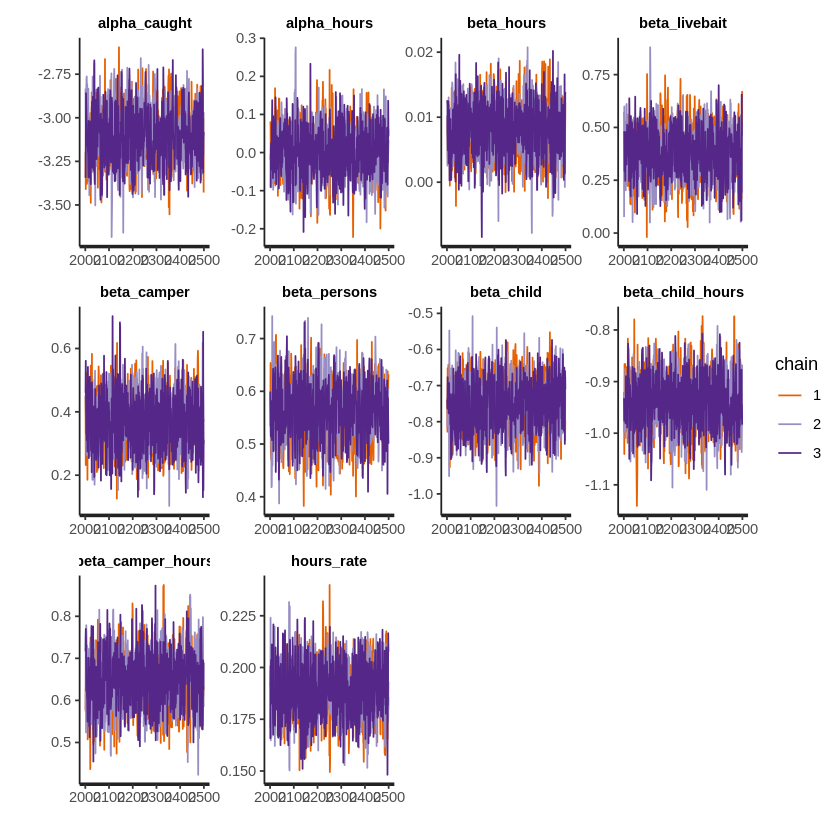

In [72]:
rstan::traceplot(gamma_model)

And then extract the samples,

In [73]:
posterior_samples <- rstan::extract(gamma_model)

And visualize the data.

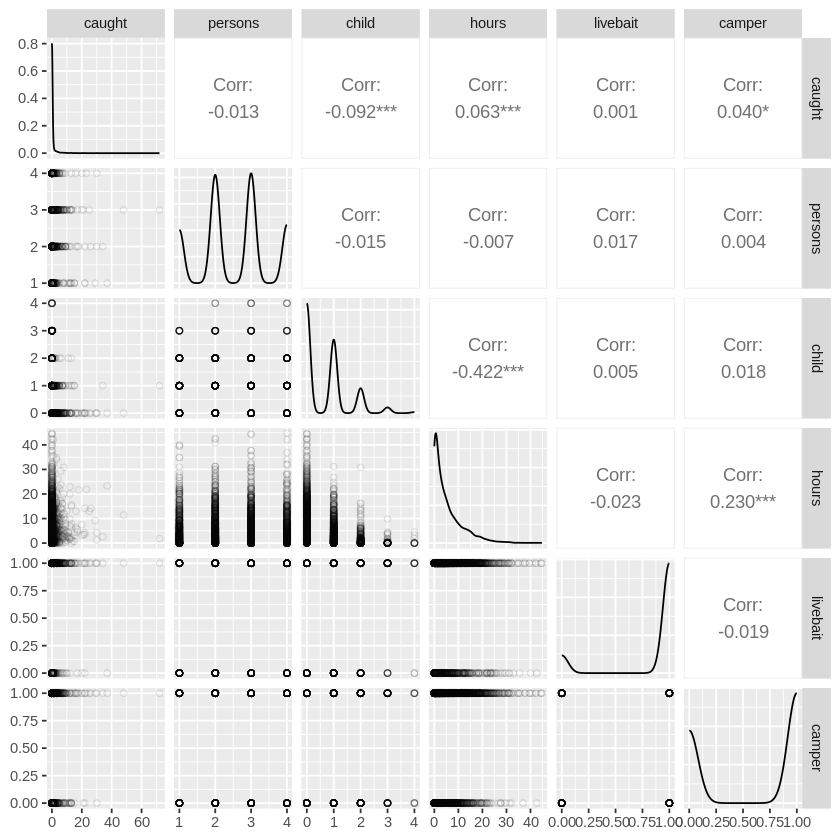

In [74]:
pred_df <- data.frame(caught = as.vector(posterior_samples$caught_pred),
                      persons = as.vector(posterior_samples$persons_pred),
                      child = as.vector(posterior_samples$child_pred),
                      hours = as.vector(posterior_samples$hours_pred),
                      livebait = as.vector(posterior_samples$livebait_pred),
                      camper = as.vector(posterior_samples$camper_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 4000), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.1, shape = 1)),)

The histograms below show that the gamma regression has produced samples with a broader range, more closely approximating the data.

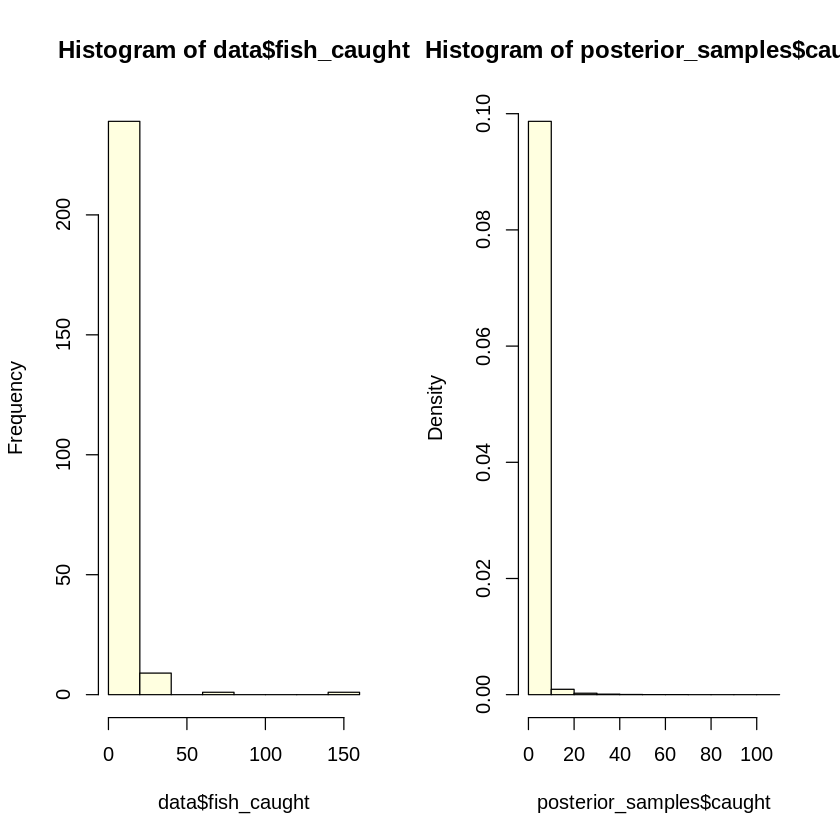

In [75]:
par(mfrow=c(1,2))
hist(data$fish_caught, breaks=10, col="lightyellow")
hist(posterior_samples$caught, breaks=10, col="lightyellow", probability=TRUE)

# Bayesian Model Evaluation

Before proceeding to the second part, in which zero-inflated versions of the above models are explored, let's break things up with some discussion of Bayesian model evaluation metrics. I've chosen to utilize functions from the <code>rethinking</code> package, such as WAIC, the Widely Available Information Criterion (Bayesian analog to the AIC), and PSIS, referring to Pareto-smoothed importance sampling for leave-one-out cross-validation (LOO-CV). This is commonly referred to as PSIS-LOO.

WAIC and PSIS-LOO are particularly suited for Bayesian models and are effective in assessing model fit while accounting for parameter uncertainty. They are often preferred in a Bayesian context where priors and posterior distributions are relevant.
Both are grounded in the Bayesian framework in that they directly integrate over the posterior distribution of the parameters rather than relying on point estimates. They use the full posterior distribution of the data likelihood, which incorporates uncertainty in the parameter estimates.


## Widely Available Information Criterion (WAIC)

WAIC is a method for estimating a model's out-of-sample predictive accuracy based on the posterior distribution and is calculated directly from the log-likelihood of the observed data. WAIC captures how well the model explains the observed data under the posterior but does not directly consider the prior.

WAIC includes a penalty term for model complexity, known as the effective number of parameters, which adjusts for potential overfitting to observed data.

Log-likelihood: for each observation $y_i$, the log-likelihood $\ell(y_i|\theta)$ represents how likely that observation is, given the parameters $\theta$.

WAIC estimates the expected log-likelihood of the observed data by integrating the log-likelihood over the posterior distribution of the parameters.

$\bar{\ell} = \mathbb{E}_{p(\theta|Y)} \left[ \sum_{i=1}^N \ell(y_i|\theta) \right] = \sum_{i=1}^N \mathbb{E}_{p(\theta|y)} [\ell(y_i|\theta)]$

WAIC includes a penalty for model complexity, estimated using the variance of the log-likelihood across the posterior samples.

$p_{\text{eff}} = \sum_{i=1}^N (Var_{p(\theta|Y)} [\ell(y_i|\theta)])$

This term quantifies how many parameters effectively contribute to the model fit, capturing the complexity of the model.

$WAIC = -2(\bar{\ell} - p_{eff})$

A lower WAIC indicates better fit to the data.

## PSIS-LOO, Pareto-Smoothed Importance Sampling LOO-CV

Leave-one-out cross-validation (LOO-CV) can provide an estimate of the log-likelihood for a given model as:

$LOO = \sum_{i=1}^N log ~p(y_i|y_{-i})$
- $y_{-i}$ is the data excluding the $i^{th}$ observation
- $p(y_i|y_{-i})$ is the predictive distribution of $y_i$ given all other observations

Importance sampling is a statistical technique used to estimate properties of a particular distribution while sampling from a different, easier-to-sample distribution. Instead of sampling directly from the target distribution, we cample from a proposal distribution that is easier to sample from and ideally similar to the target distribution. Since we're sampling from a different distribution than the target, each sample is weighted to correct for the discrepancy. The importance weight for each sample is the ratio of the target distribution's probability density to the proposal distribution's density at that sample point.

$w_i \approx \frac{p(x_i)}{q(x_i)}$
- $p(x)$ is the density of the target distribution
- $q(x)$ is the proposal distribution

$\mathbb{E}_p[f(x)] \approx \frac{1}{N} \sum_{i=1}^N w_i f(x_i)$

- where $x_i$ are samples from the proposal distribution $q(x)$.

Pareto-smoothed importance sampling applies a smoothing technique to reduce the variance of the estimates. The Pareto distribution is used to model the tails of the importance weights, meaning that if the weights are extreme, they are adjusted using the fitted Pareto distribution, allowing more robust estimation of the LOO.

The final PSIS-LOO estimate is obtained by summing the adjusted log weights.

$PSIS-LOO = \sum_{i=1}^N ~log \left( \frac{1}{K} \sum_{k=1}^K w_i^{adjusted} \right)$

The effective number of parameters $p_{eff}$ can be derived as part of the PSIS-LOO framework.

$p_{\text{eff}} = \text{Var}_i (log ~p(y_i|\theta_k))$

We'll come back to model evaluation after the zero-inflated models, using the <code>compare</code> function of the <code>rethinking</code> package to examine them all side-by-side.

# Zero-Inflated Models

Often, data has a large number of observations which can be represented as zero; perhaps more than we can comfortably model with a standard distribution. One common approach is to revise the question, diverting focus from the zeros. Another is to model the number of zeros with one model, and the rest of the data with another, but this is not ideal if the distribution used to model the non-zero data is used to including some number of zeros. A more elegant solution is to introduce another parameter into the model - a probability by which the prediction gets flipped to zero, rather than being predicted from the distribution of choice. Below will demonstrate that we can apply this method to all three types of the distributions we considered above, though it will add to our model code a little.

## Zero-Inflated Poisson Regression

Applying the concept described directly above, zero-inflated Poisson regression takes the form:

- $P(X=k)  =
\begin{cases}
  0, ~~~~~~~~~~~~~~~~\text{with probability } \pi  \\
  Pois(\lambda_i), ~~~~\text{with probability } 1-\pi \\
\end{cases}$

The mean and variance are:

- $E(X) = \lambda(1-\pi)$
- $Var(X) = \lambda(1-\pi)(1 + \lambda \pi)$

When $\pi=0$, the zero-inflated Poisson reduces to the Poisson.

The <code>data{}</code> and <code>parameters{}</code> blocks of our <code>stan</code> code are the same except for the addition of a new parameter <code>pi</code>, bounded between 0 and 1. The <code>model{}</code> block now includes some new terms.

- <code>target</code> is a built-in variable which <code>stan</code> uses to track and manage the log-probabilities while sampling. We wouldn't need to know about it unless using a custom-distribution such as our zero-inflation Poisson, as it gets initialized and handled automatically. All our inference method needs to know from us while sampling is an assessment of the log-probabilities of the samples, so the optimization of parameters is handled simply by us ensuring this information is captured in this variable.

- <code>log_mix</code> is a function used to compute the logarithm of a weighted mixture of the densities. You can see 3 components are embedded as arguments:

  - <code>pi</code> is the mixing proportion that determines the probability of drawing a zero from the zero-inflated component.

  - The value of the second argument, <code>0</code>, represents the log-probability of generating zero from the zero-inflated component. $log(1)=0$, and the probability of a zero from the zero-generating component is 1, so we pass a 0.

  - <code>poisson_lpmf(0|exp(alpha + beta * x[n])</code> represents the log-probability of drawing a zero from the Poisson component.
  
So within our <code>if</code> statement, if the $n^{th}$ instance of <code>y</code> equals 0, the log-probability of the result is either 0, or the log-probability of a zero from our fitted Poisson, depending on the value of the mixing parameter <code>pi</code>. If <code>caught[n]</code> is not equal to zero, we multiply $(1-\pi)$ by the Poisson likelihood, and since taking the log-probability, we add instead of multiply. <code>log1m</code> is just a numerically stable version of 1 minus the value of the parameter in brackets.

In [29]:
stan_code <- "

  data {
      int<lower=0> N;
      int<lower=0> caught[N];
      int<lower=0, upper=1> livebait[N];
      int<lower=0, upper=1> camper[N];
      int<lower=0> persons[N];
      int<lower=0> child[N];
      vector[N] hours;
  }

  parameters {
      real alpha_caught, alpha_hours;
      real beta_hours, beta_livebait, beta_camper, beta_persons, beta_child;
      real beta_child_hours, beta_camper_hours;
      real hours_rate;
      vector<lower=0, upper=1>[N] theta_camper, theta_livebait;
      real lambda_child;
      real<lower=0, upper=1> pi;
  }

  model {
      // Priors
      alpha_caught ~ normal(-2.56, 0.29);
      alpha_hours ~ normal(0.0025, 0.08);
      beta_livebait ~ normal(1.73, 0.24);
      beta_camper ~ normal(0.68, 0.09);
      beta_child ~ normal(-1.41, 0.1);
      beta_hours ~ normal(0, 0.003);
      beta_child_hours ~ normal(-0.94, 0.07);
      beta_camper_hours ~ normal(0.65, 0.09);
      hours_rate ~ normal(0.19, 0.02);
      lambda_child ~ normal(0.7, 0.05);
      theta_camper ~ normal(0.6, 0.05);
      theta_livebait ~ normal(0.86, 0.02);
      pi ~ normal(0.38, 0.05);

      // Likelihood
      for (n in 1:N) {


        real lambda = exp(alpha_caught +
                          beta_livebait * livebait[n] +
                          beta_camper * camper[n] +
                          beta_persons * persons[n] +
                          beta_child * child[n] +
                          beta_hours * hours[n]);


        if (caught[n] == 0) {
          target += log_mix(pi,
                            0,
                          poisson_lpmf(0 | lambda));
        } else {

          // set y given exp(alpha + beta * x[n]) ~ zip
          target += log1m(pi) + poisson_lpmf(caught[n] | exp(alpha_caught +
                          beta_livebait * livebait[n] +
                          beta_camper * camper[n] +
                          beta_persons * persons[n] +
                          beta_child * child[n] +
                          beta_hours * hours[n]));
        }

        hours[n] ~ gamma(exp(alpha_hours +
                             beta_child_hours * child[n] +
                             beta_camper_hours * camper[n]),
                         hours_rate);

        camper[n] ~ bernoulli(theta_camper);
        livebait[n] ~ bernoulli(theta_livebait);
        child[n] ~ poisson(lambda_child);
      }
  }

  generated quantities{
      int caught_pred[N];
      vector[N] hours_pred;
      int camper_pred[N];
      int livebait_pred[N];
      int child_pred[N];
      real persons_pred[N];
      real lambda_pred[N];
      vector[N] log_lik;

      for (n in 1:N) {
          camper_pred[n] = bernoulli_rng(theta_camper[n]);
          child_pred[n] = poisson_rng(lambda_child);
          persons_pred[n] = round(uniform_rng(1,4));
          livebait_pred[n] = bernoulli_rng(theta_livebait[n]);

          hours_pred[n] = gamma_rng(exp(alpha_hours +
                                        beta_child_hours * child_pred[n] +
                                        beta_camper_hours * camper_pred[n]),
                                    hours_rate);

          lambda_pred[n] = exp(alpha_caught +
                                beta_hours * hours_pred[n] +
                                beta_camper * camper_pred[n] +
                                beta_child * child_pred[n]);

          if (bernoulli_rng(pi) == 1) {
            caught_pred[n] = 0;
          } else {
            caught_pred[n] = poisson_rng(lambda_pred[n]);
          }

          log_lik[n] = poisson_lpmf(caught[n] | lambda_pred[n]);
      }
  }
  "

We run the model,

In [ ]:
caught <- data$fish_caught
livebait <- data$livebait
camper <- data$camper
persons <- data$persons
child <- data$child
hours <- data$hours
N <- nrow(data)

data_list <- list(N = N, caught = caught, hours = hours,
                  camper = camper, livebait = livebait,
                  child = child, persons = persons)

zip_model <- rstan::stan(model_code = stan_code, data = data_list, warmup = 2000,
                 iter = 2500, chains = 3, refresh = 0, cores = 8)

Inspect the traceplot,

'pars' not specified. Showing first 10 parameters by default.



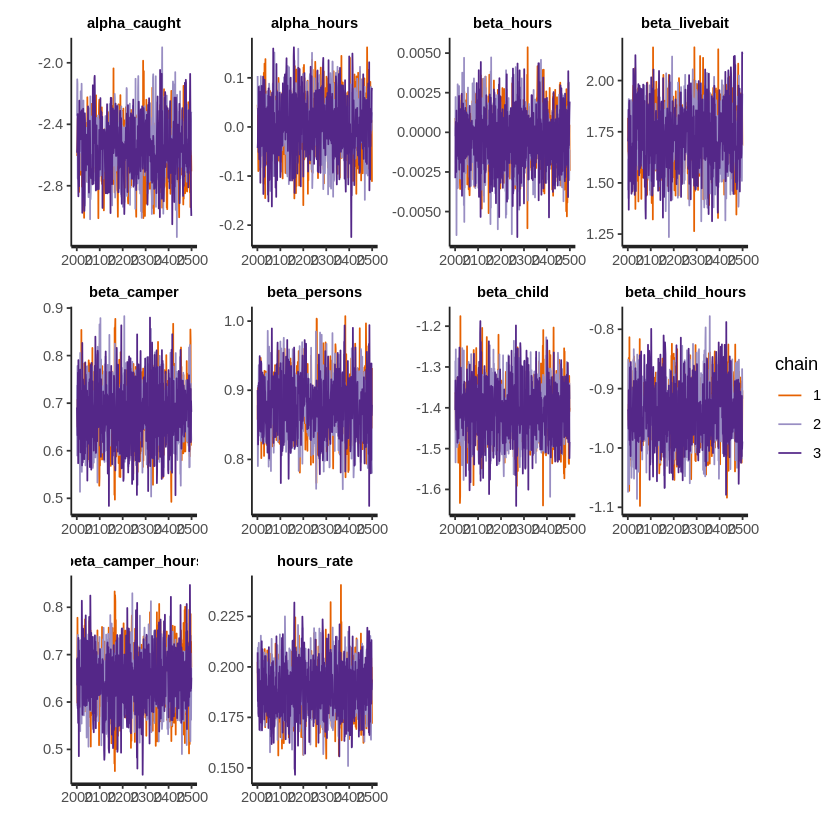

In [32]:
rstan::traceplot(zip_model)

Extract the samples,

In [33]:
posterior_samples <- rstan::extract(zip_model)

And visualize the predictions.

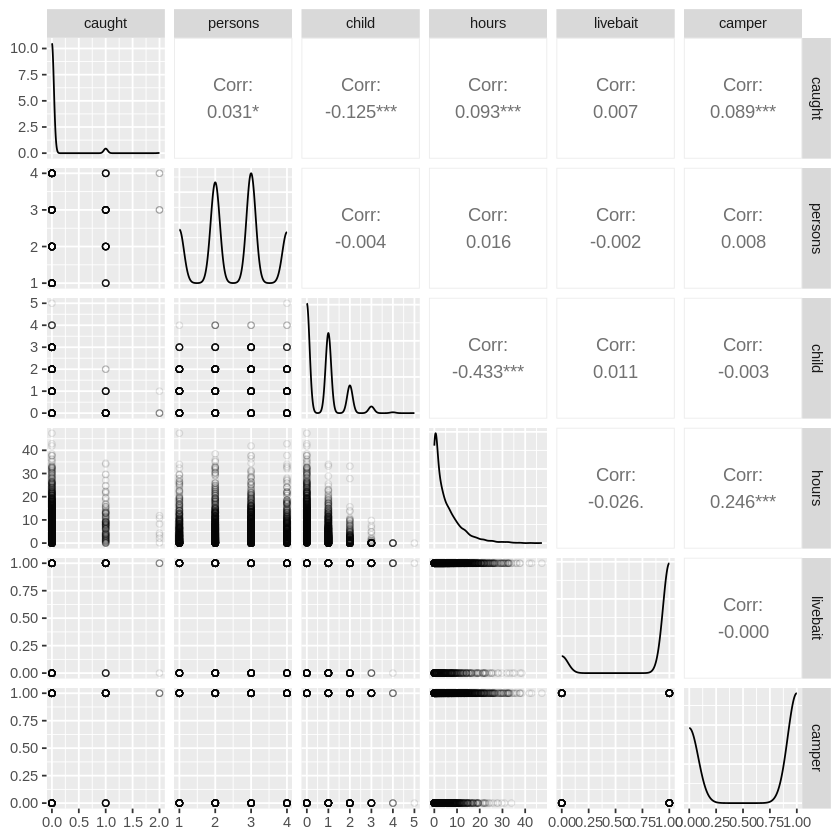

In [34]:
pred_df <- data.frame(caught = as.vector(posterior_samples$caught_pred),
                      persons = as.vector(posterior_samples$persons_pred),
                      child = as.vector(posterior_samples$child_pred),
                      hours = as.vector(posterior_samples$hours_pred),
                      livebait = as.vector(posterior_samples$livebait_pred),
                      camper = as.vector(posterior_samples$camper_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 4000), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.1, shape = 1)),)

We see from the below that it only fits slightly better than the regular Poisson model. But trust me, it's a neat trick when the data is a little more amenable, such as more restricted in range and skew.

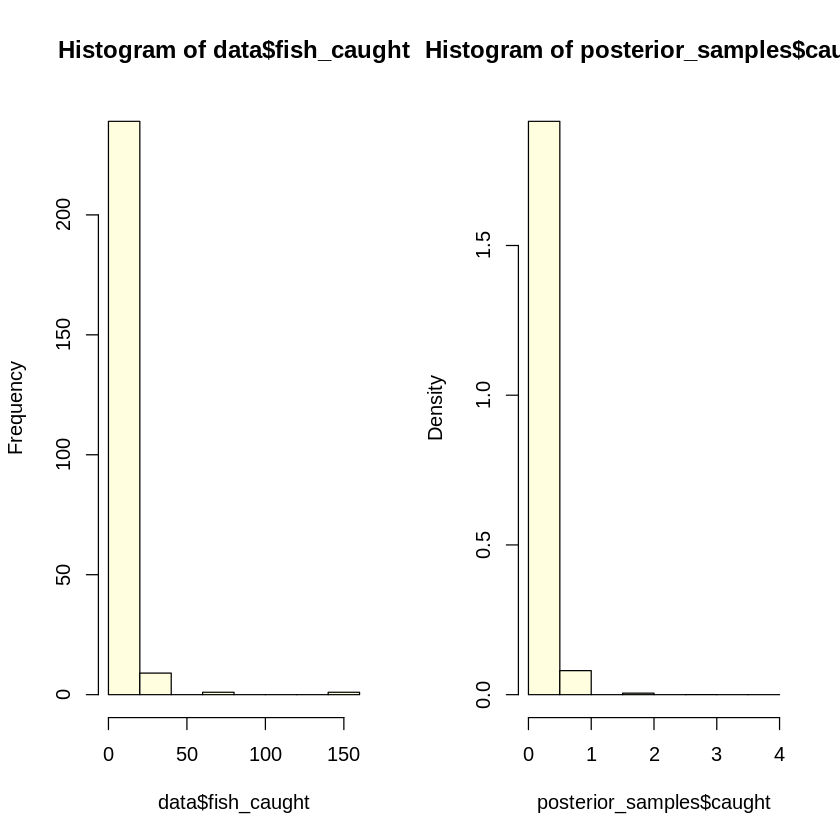

In [35]:
par(mfrow=c(1,2))
hist(data$fish_caught, breaks=10, col="lightyellow")
hist(posterior_samples$caught, breaks=10, col="lightyellow", probability=TRUE)

## Zero-Inflated Negative Binomial Regression

Zero-inflated negative binomial regression takes the form:

- $P(X=k)  =
\begin{cases}
  0, ~~~~~~~~~~~~~~~~\text{with probability } \pi  \\
  NB(\lambda_i), ~~~~~\text{with probability } 1-\pi \\
\end{cases}$

The mean and variance are:

- $E(Y) = (1 - \pi) \cdot \mu$
- $Var(Y) = (1 - \pi) \cdot \mu \cdot \left( 1 + \frac{\mu}{\phi} \right) + \pi(1 - \pi) \cdot \mu^2$

Below, we repeat the above and simply substitute the <code>neg_binomial_2</code> distribution for the <code>poisson</code>. This involves providing the additional 'dispersion' parameter, <code>phi_caught</code>, and providing it with a prior distribution.

In [46]:
stan_code <- "

  data {
      int<lower=0> N;
      int<lower=0> caught[N];
      int<lower=0, upper=1> livebait[N];
      int<lower=0, upper=1> camper[N];
      int<lower=0> persons[N];
      int<lower=0> child[N];
      vector[N] hours;
  }

  parameters {
      real alpha_caught, alpha_hours;
      real beta_hours, beta_livebait, beta_camper, beta_persons, beta_child;
      real beta_child_hours, beta_camper_hours;
      real hours_rate;
      vector<lower=0, upper=1>[N] theta_camper, theta_livebait;
      real lambda_child;
      real<lower=0, upper=1> pi;
      real<lower=0> phi_caught;
  }

  model {
      // Priors
      alpha_caught ~ normal(-3.0, 0.51);
      alpha_hours ~ normal(0.006, 0.08);
      beta_livebait ~ normal(1.57, 0.42);
      beta_camper ~ normal(0.46, 0.24);
      beta_child ~ normal(-1.73, 0.22);
      beta_hours ~ normal(0.012, 0.015);
      beta_child_hours ~ normal(-0.94, 0.07);
      beta_camper_hours ~ normal(0.65, 0.09);
      hours_rate ~ normal(0.19, 0.02);
      lambda_child ~ normal(0.7, 0.05);
      theta_camper ~ normal(0.6, 0.05);
      theta_livebait ~ normal(0.86, 0.02);
      pi ~ beta(1,1);
      phi_caught ~ normal(0.55, 0.09);

      // Likelihood
      for (n in 1:N) {

        real mu = exp(alpha_caught +
                      beta_livebait * livebait[n] +
                      beta_camper * camper[n] +
                      beta_persons * persons[n] +
                      beta_child * child[n] +
                      beta_hours * hours[n]);

        if (caught[n] == 0) {
          target += log_mix(pi,
                            0,
                          neg_binomial_2_lpmf(0 | mu, phi_caught));
        } else {

          // set y given exp(alpha + beta * x[n]) ~ zip
          target += log1m(pi) + neg_binomial_2_lpmf(caught[n] | exp(alpha_caught +
                          beta_livebait * livebait[n] +
                          beta_camper * camper[n] +
                          beta_persons * persons[n] +
                          beta_child * child[n] +
                          beta_hours * hours[n]), phi_caught);
        }

        hours[n] ~ gamma(exp(alpha_hours +
                             beta_child_hours * child[n] +
                             beta_camper_hours * camper[n]),
                         hours_rate);

        camper[n] ~ bernoulli(theta_camper);
        livebait[n] ~ bernoulli(theta_livebait);
        child[n] ~ poisson(lambda_child);
      }
  }

  generated quantities{
      int caught_pred[N];
      vector[N] hours_pred;
      int camper_pred[N];
      int livebait_pred[N];
      int child_pred[N];
      real persons_pred[N];
      real mu_pred[N];
      vector[N] log_lik;

      for (n in 1:N) {
          camper_pred[n] = bernoulli_rng(theta_camper[n]);
          child_pred[n] = poisson_rng(lambda_child);
          persons_pred[n] = round(uniform_rng(1,4));
          livebait_pred[n] = bernoulli_rng(theta_livebait[n]);

          hours_pred[n] = gamma_rng(exp(alpha_hours +
                                        beta_child_hours * child_pred[n] +
                                        beta_camper_hours * camper_pred[n]),
                                    hours_rate);

          mu_pred[n] = exp(alpha_caught +
                      beta_livebait * livebait[n] +
                      beta_camper * camper[n] +
                      beta_persons * persons[n] +
                      beta_child * child[n] +
                      beta_hours * hours[n]);

          if (bernoulli_rng(pi) == 1) {
            caught_pred[n] = 0;
          } else {
            caught_pred[n] = neg_binomial_2_rng(mu_pred[n], phi_caught);
          }

          log_lik[n] = neg_binomial_2_lpmf(caught[n] | mu_pred[n], phi_caught);
      }
  }
  "

Run the model,

In [ ]:
caught <- data$fish_caught
livebait <- data$livebait
camper <- data$camper
persons <- data$persons
child <- data$child
hours <- data$hours
N <- nrow(data)

data_list <- list(N = N, caught = caught, hours = hours,
                  camper = camper, livebait = livebait,
                  child = child, persons = persons)

zinb_model <- rstan::stan(model_code = stan_code, data = data_list, warmup = 2000,
                 iter = 2500, chains = 3, refresh = 0, cores = 8)

Inspect the traces,

'pars' not specified. Showing first 10 parameters by default.



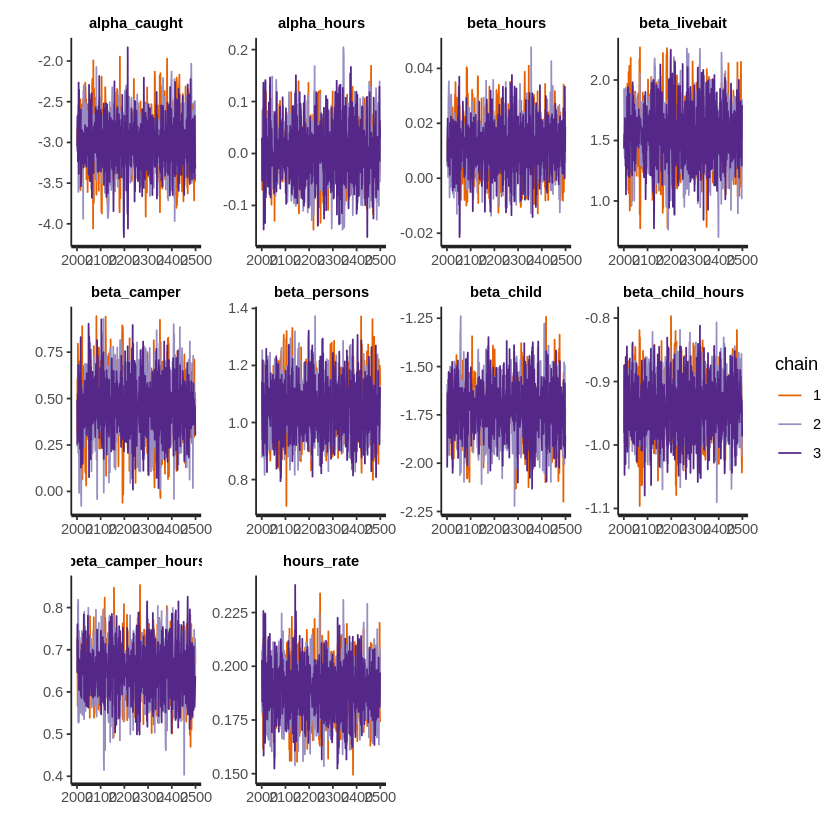

In [51]:
rstan::traceplot(zinb_model)

Extract the samples,

In [52]:
posterior_samples <- rstan::extract(zinb_model)

And visualize the results.

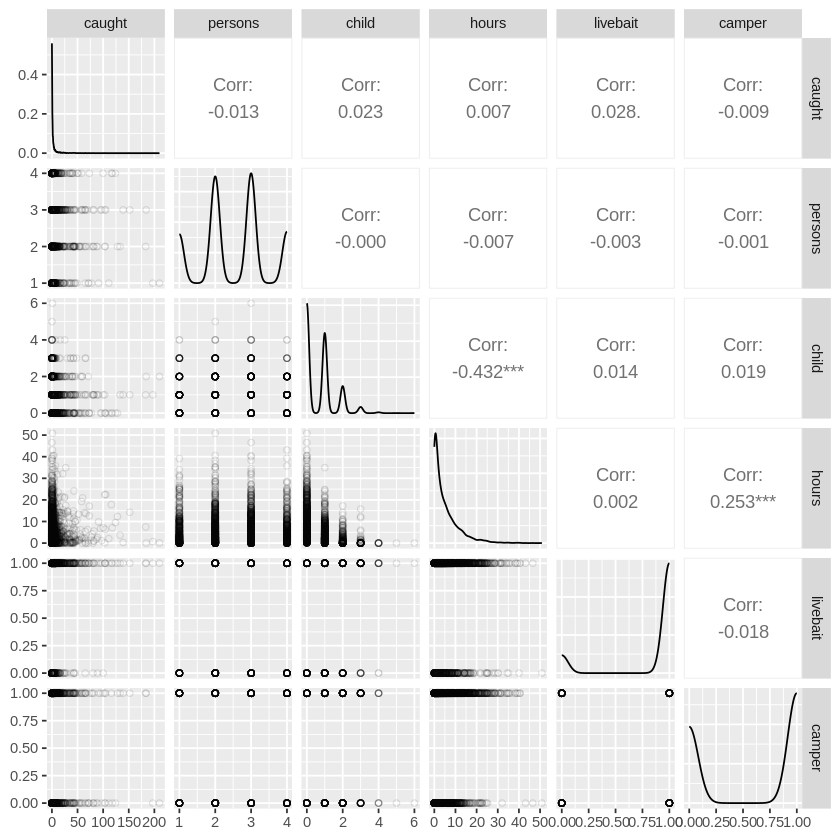

In [53]:
pred_df <- data.frame(caught = as.vector(posterior_samples$caught_pred),
                      persons = as.vector(posterior_samples$persons_pred),
                      child = as.vector(posterior_samples$child_pred),
                      hours = as.vector(posterior_samples$hours_pred),
                      livebait = as.vector(posterior_samples$livebait_pred),
                      camper = as.vector(posterior_samples$camper_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 4000), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.1, shape = 1)),)

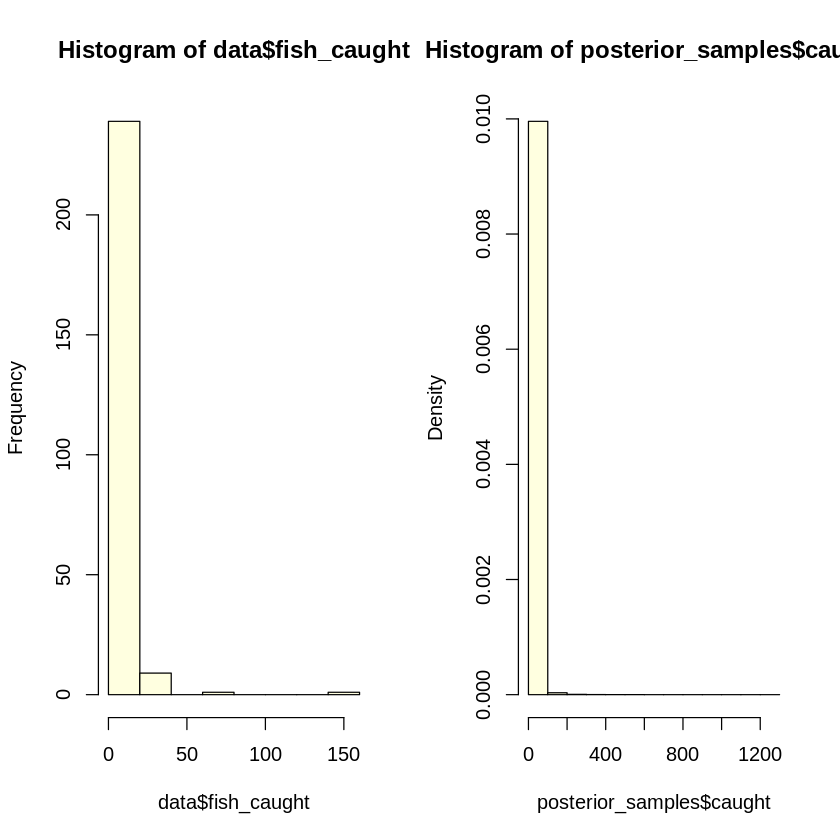

In [54]:
par(mfrow=c(1,2))
hist(data$fish_caught, breaks=10, col="lightyellow")
hist(posterior_samples$caught, breaks=10, col="lightyellow", probability=TRUE)

## Zero-Augmented Gamma Regression

Repeating the gamma regression procedure above, mixed with the zero-inflated accounting method, we arrive at zero-augmented gamma regression. Technically, small-constant augmented gamma regression, because absolute zeros are not allowed. But we adhere to this constraint by adding a small constant to <code>caught</code>, which won't matter because we round the predictions, and once again we parameterize our dependent variable as a gamma with particular shape and rate.

The distribution takes the form:

- $P(X=k)  =
\begin{cases}
  0, ~~~~~~~~~~~~~~~~~~~\text{with probability } \pi  \\
  \text{Gamma}(\lambda_i), ~~\text{with probability } 1-\pi \\
\end{cases}$

The mean and variance are:

- $E(Y) = (1 - \pi) \cdot \frac{\alpha}{\beta}$
- $Var(Y) = (1 - \pi) \cdot \frac{\alpha}{\beta^2} + \pi(1 - \pi) \cdot \left( \frac{\alpha}{\beta} \right)^2$

In [58]:
stan_code <- "

  data {
      int<lower=0> N;
      real<lower=0> caught[N];
      int<lower=0, upper=1> livebait[N];
      int<lower=0, upper=1> camper[N];
      int<lower=0> persons[N];
      int<lower=0> child[N];
      vector[N] hours;
  }

  parameters {
      real alpha_caught, alpha_hours;
      real beta_hours, beta_livebait, beta_camper, beta_persons, beta_child;
      real beta_child_hours, beta_camper_hours;
      real hours_rate;
      vector<lower=0, upper=1>[N] theta_camper, theta_livebait;
      real lambda_child;
      real<lower=0, upper=1> pi;
      real<lower=0> rate_caught;
  }

  model {
      // Priors
      alpha_caught ~ normal(-3.1, 0.25);
      alpha_hours ~ normal(0.005, 0.08);
      beta_livebait ~ normal(0.38, 0.19);
      beta_camper ~ normal(0.37, 0.13);
      beta_child ~ normal(-0.75, 0.11);
      beta_hours ~ normal(0.008, 0.006);
      beta_child_hours ~ normal(-0.94, 0.07);
      beta_camper_hours ~ normal(0.65, 0.09);
      hours_rate ~ normal(0.19, 0.02);
      lambda_child ~ normal(0.7, 0.05);
      theta_camper ~ normal(0.6, 0.05);
      theta_livebait ~ normal(0.86, 0.02);
      pi ~ beta(1,1);
      rate_caught ~ gamma(0.38, 4.73);

      // Likelihood
      for (n in 1:N) {

        real shape = exp(alpha_caught +
                          beta_livebait * livebait[n] +
                          beta_camper * camper[n] +
                          beta_persons * persons[n] +
                          beta_child * child[n] +
                          beta_hours * hours[n]);

        if (caught[n] == 0) {
          target += log_mix(pi,
                            0+0.001,
                          gamma_lpdf(0+0.001 | shape, rate_caught));
        } else {

          target += log1m(pi) + gamma_lpdf(caught[n] | shape, rate_caught);
        }

        hours[n] ~ gamma(exp(alpha_hours +
                             beta_child_hours * child[n] +
                             beta_camper_hours * camper[n]),
                         hours_rate);

        camper[n] ~ bernoulli(theta_camper);
        livebait[n] ~ bernoulli(theta_livebait);
        child[n] ~ poisson(lambda_child);
      }
  }

  generated quantities{
      real caught_pred[N];
      vector[N] hours_pred;
      int camper_pred[N];
      int livebait_pred[N];
      int child_pred[N];
      real persons_pred[N];
      real shape_pred[N];
      vector[N] log_lik;

      for (n in 1:N) {
          camper_pred[n] = bernoulli_rng(theta_camper[n]);
          child_pred[n] = poisson_rng(lambda_child);
          persons_pred[n] = round(uniform_rng(1,4));
          livebait_pred[n] = bernoulli_rng(theta_livebait[n]);

          hours_pred[n] = gamma_rng(exp(alpha_hours +
                                        beta_child_hours * child_pred[n] +
                                        beta_camper_hours * camper_pred[n]),
                                    hours_rate);

          if (bernoulli_rng(pi) == 1) {
            caught_pred[n] = 0;
          } else {
            caught_pred[n] = round(gamma_rng(exp(alpha_caught +
                                beta_hours * hours_pred[n] +
                                beta_camper * camper_pred[n] +
                                beta_child * child_pred[n]), rate_caught));
          }

          shape_pred[n] = exp(alpha_caught +
                                beta_hours * hours_pred[n] +
                                beta_camper * camper_pred[n] +
                                beta_child * child_pred[n]);

          log_lik[n] = gamma_lpdf(caught[n] | shape_pred[n], rate_caught);
      }
  }
  "

Run model,

In [ ]:
caught <- data$fish_caught
livebait <- data$livebait
camper <- data$camper
persons <- data$persons
child <- data$child
hours <- data$hours
N <- nrow(data)

data_list <- list(N = N, caught = caught+0.001, hours = hours,
                  camper = camper, livebait = livebait,
                  child = child, persons = persons)

zagamma_model <- rstan::stan(model_code = stan_code, data = data_list, warmup = 2000,
                 iter = 2500, chains = 3, refresh = 0, cores = 8)

Inspect traceplot,

'pars' not specified. Showing first 10 parameters by default.



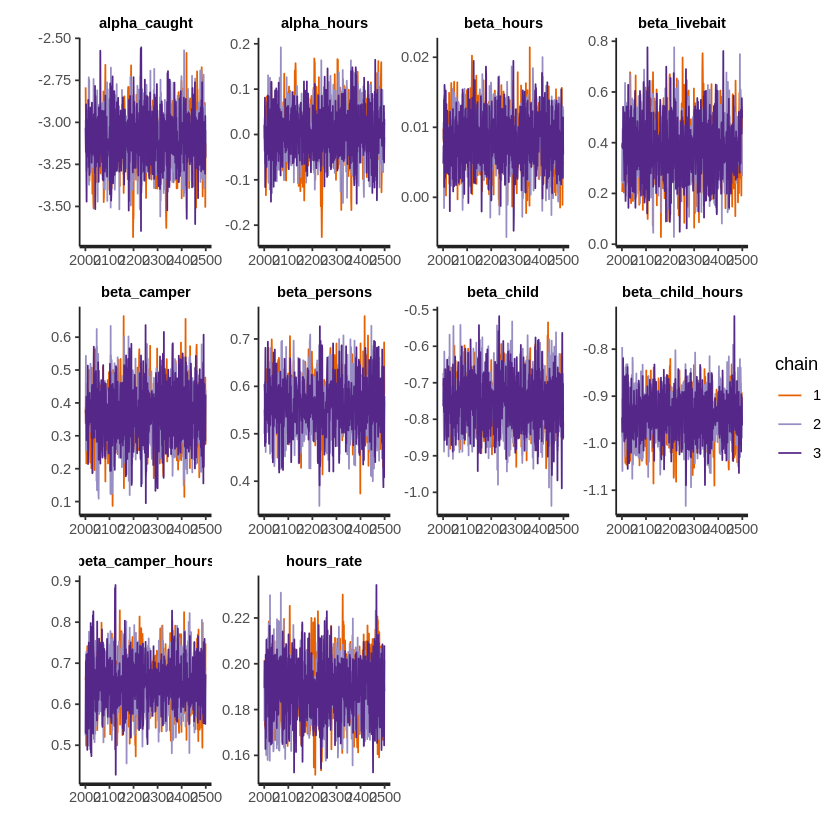

In [61]:
rstan::traceplot(zagamma_model)

Extract,

In [62]:
posterior_samples <- rstan::extract(zagamma_model)

Visualize.

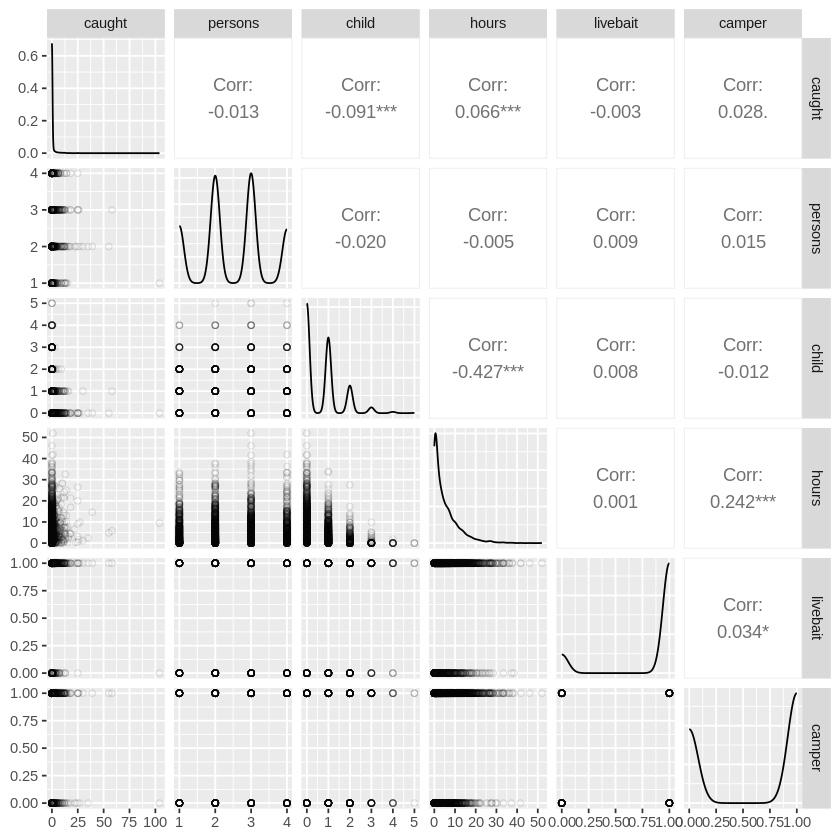

In [63]:
pred_df <- data.frame(caught = as.vector(posterior_samples$caught_pred),
                      persons = as.vector(posterior_samples$persons_pred),
                      child = as.vector(posterior_samples$child_pred),
                      hours = as.vector(posterior_samples$hours_pred),
                      livebait = as.vector(posterior_samples$livebait_pred),
                      camper = as.vector(posterior_samples$camper_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 4000), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.1, shape = 1)),)

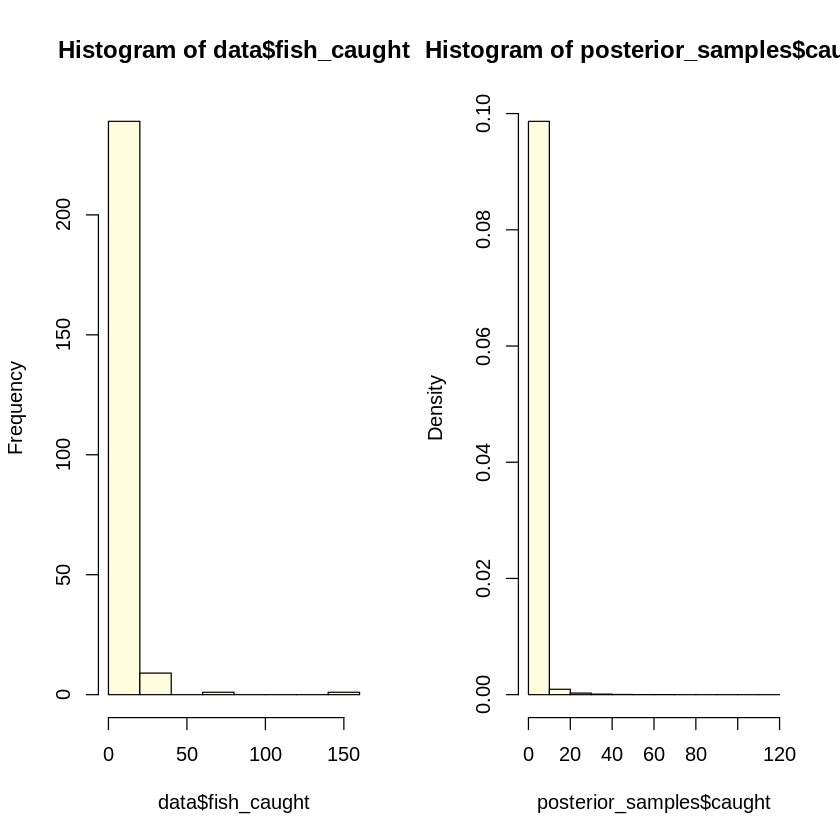

In [64]:
par(mfrow=c(1,2))
hist(data$fish_caught, breaks=10, col="lightyellow")
hist(posterior_samples$caught, breaks=10, col="lightyellow", probability=TRUE)

# Model Comparison

Finally, we'll compare model performance, focusing on the WAIC metric. We could also use the following <code>compare</code> function to produce LOO scores, by passing <code>func=LOO</code>.

In [76]:
rethinking::compare(poisson_model,
                    nb_model,
                    gamma_model,
                    zip_model,
                    zinb_model,
                    zagamma_model)

,WAIC,SE,dWAIC,dSE,pWAIC,weight
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
gamma_model,332.3544,141.73349,0.000000e+00,NA,90.873707,8.569189e-01
zagamma_model,335.9343,142.57100,3.579864e+00,2.697649e+00,93.345406,1.430811e-01
zinb_model,809.7241,58.22324,4.773697e+02,9.916127e+01,7.568791,1.876848e-104
zip_model,114722.7923,68968.06457,1.143904e+05,6.905368e+04,54117.690873,0.000000e+00
poisson_model,165826.6747,99745.49298,1.654943e+05,9.989276e+04,79046.628452,0.000000e+00
nb_model,167474.9948,101466.15927,1.671426e+05,1.016170e+05,82370.650524,0.000000e+00


We see that the gamma models perform best on the data, with the zero-augmented one performing slightly worse, and the ZINB model performing marginally worse, with the others quite far behind. Below are definitions of some of the terms you see above.

- <code>WAIC</code>: a Bayesian information criterion that estimates out-of-sample predictive accuracy by averaging the log-likelihood of each data point over the posterior samples, adjusting for model complexity. It's frequentist analog is the Akaike Information Criterion (AIC).

<code>pWAIC</code>: the effective number of parameters in the model and is calculated based on the variance of the log-likelihood. Serves as a penalty for model complexity in WAIC. High values suggest more complex models.

<code>SE</code> (Standard Error): uncertainty around these estimates.

<code>dWAIC</code>: the delta in WAIC; the difference between each model and the best model.

<code>Weights</code>: the relative likelihood of each model being the best one.

# References

- Stan User Guide https://mc-stan.org/docs/stan-users-guide/index.html